In [1]:
import pandas as pd # Išvedimui
import numpy as np  # Atsitiktinių skaičių generavimui ir skaičiavimams
import matplotlib.pyplot as plt

from itertools import product # Svorių radimui

### Generuojami tiesiškai atsikiriami taškai su polinėmis koordinatėmis

- 1 klasės taškai bus atsitiktinai generuoti su polinėmis koordinatėmis, kurios posūkis yra atsitiktinis skaičius tarp 25 ir 44 laipsnių, o ilgis - atsitiktinis skaičius tarp 5 ir 15.
- 2 klasės taškai, atitinkamai polinėmis koordinatėmis, kurios posūkis tarp 26 ir 65 laipsnių, o ilgis taip pat tarp 5 ir 15.

In [2]:
rng = np.random.default_rng(seed=42)
n_generate = 10

# Atsitiktiniai posūkiai
degree_class_1 = rng.integers(low=25, high=44, size=10)
degree_class_2 = rng.integers(low=46, high=65, size=10)

# Atsitiktiniai ilgiai
length_class_1 = rng.integers(low=5, high=15, size=10)
length_class_2 = rng.integers(low=5, high=15, size=10)

In [3]:
def translate_polar_to_decartes(degree, length) -> np.float64:
    """ Tradicinė formulė, verčiant poliarines koordinates į dekarto (Euklidines). """
    x = np.cos(degree / 180 * np.pi) * length
    y = np.sin(degree / 180 * np.pi) * length
    return x,y

#### Sugeneruojame dvi klases

In [4]:
class_1_x = []
class_1_y = []

for degree, length in zip(degree_class_1, length_class_1):
    # Polerines verčiame į dekarto
    x, y = translate_polar_to_decartes(degree, length)

    class_1_x.append(x)
    class_1_y.append(y)

In [5]:
class_2_x = []
class_2_y = []

for degree, length in zip(degree_class_2, length_class_2):
    x, y = translate_polar_to_decartes(degree, length)
    class_2_x.append(x)
    class_2_y.append(y)

#### Grafikas tiesiškai atskirtinų duomenų

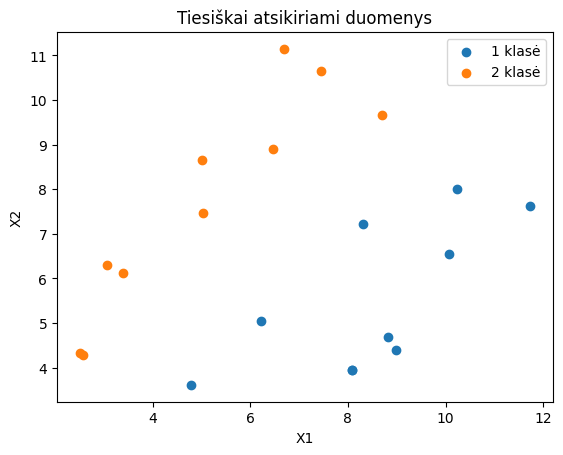

In [6]:
# Duomenys nubraižomi sklaidos diagrama
plt.scatter(class_1_x, class_1_y, label='1 klasė')
plt.scatter(class_2_x, class_2_y, label='2 klasė')

# Grafiko parametrai
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Tiesiškai atsikiriami duomenys')
plt.legend()

plt.show()

#### Klasių duomenys surašomi į klasifikavimui geresnę duomenų struktūrą ir išsaugoma.

In [7]:
class_1 = [{'x': x, 'y': y, 'class': 0} for x,y in zip(class_1_x, class_1_y)]
class_2 = [{'x': x, 'y': y, 'class': 1} for x,y in zip(class_2_x, class_2_y)]

df = pd.DataFrame(class_1 + class_2)
df.to_csv('data_generated.csv', index=False)

#### Implementuojamos leistinos aktyvacijos funkcijos

In [8]:
AKTIVACIJOS_FUNKCIJA = {
    'slenkstine': lambda x: 1 if x > 0 else 0,
    'sigmoidine': lambda x: 1 / (1 + np.exp(-1 * x))
}

## Neurono klasė

In [9]:
class PaprastasNeuronas:
    def __init__(self, activation: str):
        """
        Inicializuojame svorius su nuliais.
        :param activation: Aktyvacijos funkcija.
        """
        assert activation in AKTIVACIJOS_FUNKCIJA,\
            'Pateikite sigmodine arba slekstine aktyvacijos funkcija'

        self.activation = AKTIVACIJOS_FUNKCIJA[activation]
        self.initialize_weights()

    def initialize_weights(self):
        """ Inicializuojami svoriai su nuliais """
        self.w_1 = 0
        self.w_2 = 0
        self.b = 0

    def set_weights(self, point: tuple):
        """ Svorių priskyrimas """
        self.w_1, self.w_2, self.b = point

    def __call__(self, x_1: float, x_2: float):
        """ Apskaičiuojama neurono išvestis """
        a = x_1 * self.w_1 + x_2 * self.w_2 + self.b
        return self.activation(a)

    def predict(self, x_1, x_2):
        """ Klasifikuojame duomenis pagal kintamųjų x_1, x_2 reikšmes """
        return 1 if self(x_1, x_2) >= 0.5 else 0

In [10]:
def check_if_all_classfied(self, df: pd.DataFrame):
    """ 
    Patikriname, ar klasifikavimas veikia 100%
    :param df: Duomenys
    """

    # Iteruoti per eilutes
    for _, row in df.iterrows():
        # Patikrinti, ar klasifikacija neveikia
        if self.predict(row['x'], row['y']) != row['class']:
            return False

    return True

# Pridedame metodą prie klasės
setattr(PaprastasNeuronas, 'check_if_all_classfied', check_if_all_classfied)

In [11]:
def find_weights(self, df: pd.DataFrame, n_outputs: int = 3):
    """
    Svoriai surandami tokiu principu: 
    - pereiname visus skaičių trejetus tarp -1 ir 1 (10x10x10 tenzoriaus)
    - ištestuojame, ar atintinka 3 punkto reikalavimus, jei atitinka pridedam prie rezultatų
    - kai gauname 3 rezultatus, grąžiname
    """

    # 10x10x10 lentelė
    intervals = np.linspace(-1, 1, num=10)
    grid = list( product(intervals, repeat=3) )

    # Iteruojame per variantus
    results = []
    for point in grid:
        if len(results) >= 3:
            return results

        # Set weights
        self.set_weights(point)

        # Check if the model classifies all of the points correctly
        if self.check_if_all_classfied(df):
            results.append( tuple(point) )

    return results

# Pridedame metodą prie klasės
setattr(PaprastasNeuronas, 'find_weights', find_weights)

### Implementuoti neuronus ir surasti svorius

In [12]:
neuronas_slenkstine = PaprastasNeuronas('slenkstine')
svoriai_slenkstine = neuronas_slenkstine.find_weights(df)

In [13]:
neuronas_sigmoid = PaprastasNeuronas('sigmoidine')
svoriai_sigmoidine = neuronas_sigmoid.find_weights(df)

### Nubraižyti grafikus

In [14]:
def plot_line(point: tuple, xlim: tuple, *args, **kwargs):
    w_1, w_2, b = point

    x_1 = np.linspace(xlim[0], xlim[1], num=100)
    # Rearranging x_1 * w_1 + x_2 * w_2 + b = 0 
    x_2 = (x_1 * w_1 + b) / (-1 * w_2)

    plt.plot(x_1, x_2, *args, **kwargs)

In [15]:
COLORS = ['#a020f0', '#f0a020', '#20f0a0']

In [16]:
def plot_lines_points(
    points: list[tuple],
    xlim: tuple,
    title: str
):
    plt.scatter(class_1_x, class_1_y, label='1 klasė', color='#8B0000')
    plt.scatter(class_2_x, class_2_y, label='2 klasė', color='#008B8B')

    for ix, point in enumerate(points):
        plot_line(point, xlim=xlim, label=f'{ix+1} tiesė',
                  color=COLORS[ix])
    
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title(title)
    plt.legend()

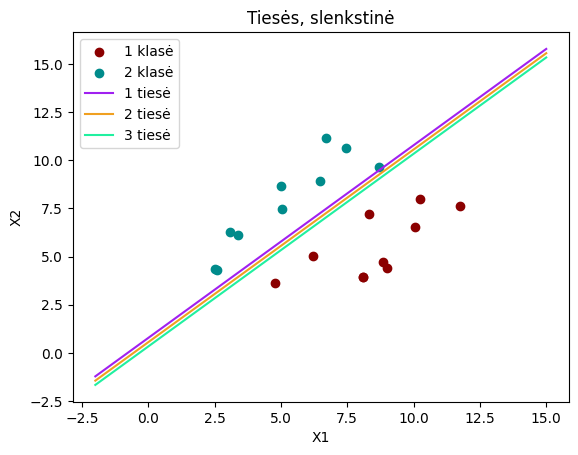

In [17]:
plot_lines_points(svoriai_slenkstine, (-2, 15), 
         'Tiesės, slenkstinė')

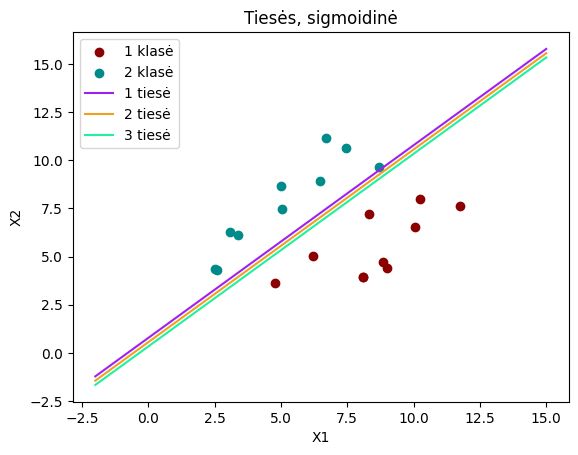

In [18]:
plot_lines_points(svoriai_sigmoidine, (-2, 15), 
         'Tiesės, sigmoidinė')

In [19]:
def plot_all(
    points: list[tuple],
    xlim: tuple,
    title: str
):
    plot_lines_points(points, xlim, title)

    for ix, point in enumerate(points):
        x, y = 0, -1 * point[2] / point[1]
        dx, dy = point[0], point[1]

        plt.arrow(
            x, y, dx, dy, color=COLORS[ix],      
            length_includes_head=True,
            linewidth=1.5, head_width=0.2, head_length=0.1
        )

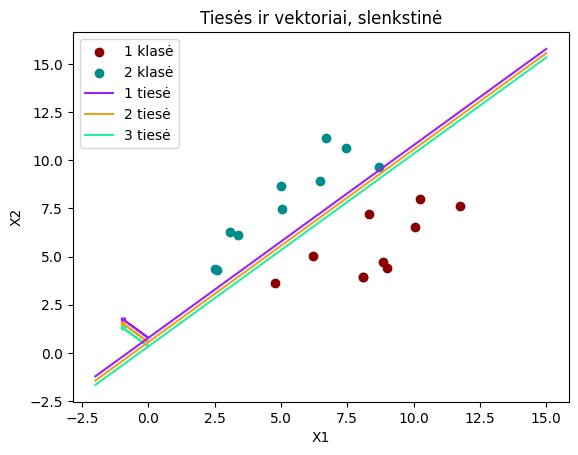

In [20]:
plot_all(svoriai_slenkstine, (-2, 15),
         'Tiesės ir vektoriai, slenkstinė')

plt.show()

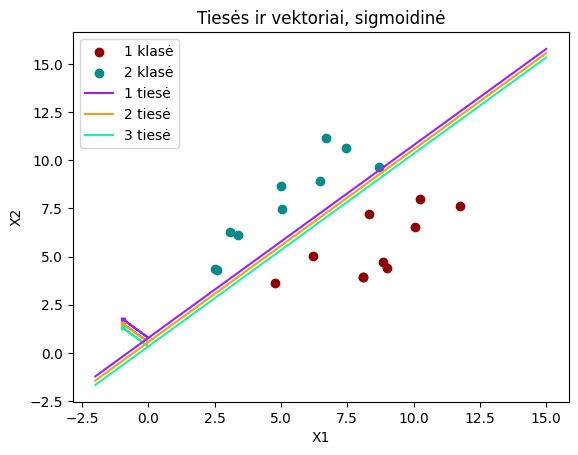

In [21]:
plot_all(svoriai_sigmoidine, (-2, 15), 
         'Tiesės ir vektoriai, sigmoidinė')